# Diamonds for Sara
### Diamond Price Prediction and Deal-Finding Model
The goal of this project is to predict the fair market price of diamonds using a machine learning model, and then identify diamonds that are currently listed below their predicted value i.e., good deals.

Dataset consists of 6,000 diamonds with the following features:
- Carat Weight - physical weight of the stone
- Cut - quality of the cut (e.g., Ideal, Very Good, Good, Fair, Poor)
- Color - color grade (D through J, D being most colorless)
- Clarity - inclusion grade (FL through I2)
- Polish - surface finish quality
- Symmetry - facet alignment quality
- Report - certifying laboratory (GIA, AGSL, etc.)
- Price - target variable (USD)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder  # Fix #4: use OrdinalEncoder for ordered categories
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data

In [9]:
data = pd.read_excel('data.xlsx')
print(data.shape)
print(data.dtypes)
display(data.head())

(6000, 9)
ID                int64
Carat Weight    float64
Cut              object
Color            object
Clarity          object
Polish           object
Symmetry         object
Report           object
Price             int64
dtype: object


,ID,Carat Weight,Cut,Color,Clarity,Polish,Symmetry,Report,Price
0,1,1.10,Ideal,H,SI1,VG,EX,GIA,5169
1,2,0.83,Ideal,H,VS1,ID,ID,AGSL,3470
2,3,0.85,Ideal,H,SI1,EX,EX,GIA,3183
3,4,0.91,Ideal,E,SI1,VG,VG,GIA,4370
4,5,0.83,Ideal,G,SI1,EX,EX,GIA,3171


## 2. Encode Categorical Features

Using OrdinalEncoder with explicit grade ordering, this preserves the natural ordering of diamond quality grades (e.g., Fair < Good < Very Good < Ideal),
allowing the model to learn the correct directional relationship.

In [10]:
# Define ordinal grade orders (low to high quality)
cut_order      = ['Fair', 'Good', 'Very Good', 'Ideal']
color_order    = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_order  = ['I2', 'I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF', 'FL']
polish_order   = ['P', 'F', 'G', 'VG', 'EX', 'ID']
symmetry_order = ['P', 'F', 'G', 'VG', 'EX', 'ID']

ordered_cols = ['Cut', 'Color', 'Clarity', 'Polish', 'Symmetry']
enc = OrdinalEncoder(
    categories=[cut_order, color_order, clarity_order, polish_order, symmetry_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
data[ordered_cols] = enc.fit_transform(data[ordered_cols])

# Report lab is nominal (no order) 
data['Report'] = data['Report'].astype('category').cat.codes

print('Encoding complete')
data.head()

Encoding complete.


,ID,Carat Weight,Cut,Color,Clarity,Polish,Symmetry,Report,Price
0,1,1.10,3.0,2.0,3.0,3.0,4.0,1,5169
1,2,0.83,3.0,2.0,5.0,5.0,5.0,0,3470
2,3,0.85,3.0,2.0,3.0,4.0,4.0,1,3183
3,4,0.91,3.0,5.0,3.0,3.0,3.0,1,4370
4,5,0.83,3.0,3.0,3.0,4.0,4.0,1,3171


## 3. Train/Test Split and Model Training

In [4]:
X = data.drop(['Price', 'ID'], axis=1)
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mape = (abs((y_test - y_pred) / y_test)).mean() * 100
r2   = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f'MAE:  ${mae:,.2f}')
print(f'MAPE: {mape:.2f}%')
print(f'R²:   {r2:.4f}')
print(f'RMSE: ${rmse:,.2f}')

MAE:  $635.78
MAPE: 5.26%
R²:   0.9864
RMSE: $1,202.73


c:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 4. Feature Importance

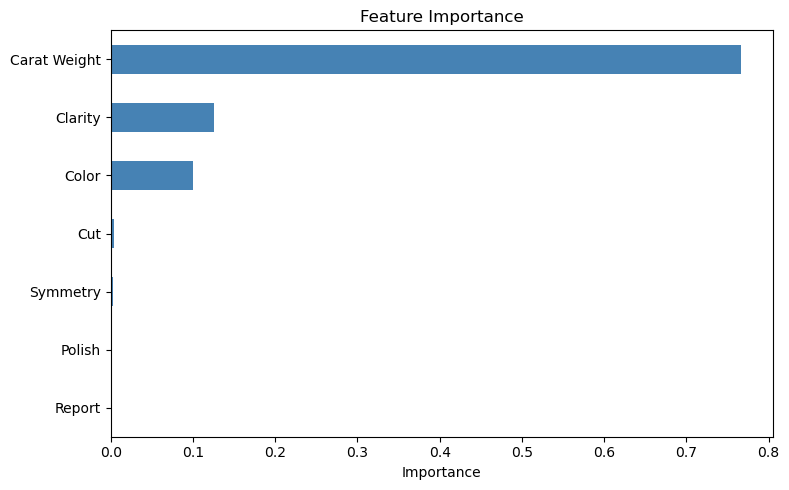

Carat Weight    0.766690
Clarity         0.125072
Color           0.100032
Cut             0.003972
Symmetry        0.002207
Polish          0.001747
Report          0.000279
dtype: float64


In [5]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(feature_importances.sort_values(ascending=False))

## 5. Identify Good Deals

Good deals are computed only on the test set (unseen data) to avoid leakage.

In [11]:
# Work only with test set for deal detection
test_df = X_test.copy()
test_df['Price'] = y_test.values
test_df['Predicted_Price'] = y_pred

test_df['Price_Difference'] = test_df['Predicted_Price'] - test_df['Price']
test_df['Good_Deal'] = test_df['Price_Difference'] > 0

print(f"Good deals in test set: {test_df['Good_Deal'].sum()} / {len(test_df)}")
test_df[test_df['Good_Deal']].sort_values('Price_Difference', ascending=False).head(10)

Good deals in test set: 602 / 1200


,Carat Weight,Cut,Color,Clarity,Polish,Symmetry,Report,Price,Predicted_Price,Price_Difference,Good_Deal
2995,1.91,2.0,4.0,8.0,2.0,2.0,1,28557,40470.670000,11913.670000,True
5559,1.84,2.0,5.0,8.0,3.0,3.0,1,35410,41833.570000,6423.570000,True
5563,2.61,2.0,5.0,8.0,4.0,3.0,1,67240,73430.830000,6190.830000,True
2582,2.23,3.0,6.0,4.0,3.0,4.0,1,27942,33513.280000,5571.280000,True
3256,2.59,2.0,5.0,3.0,4.0,4.0,1,25158,29578.170000,4420.170000,True
2900,2.03,3.0,2.0,5.0,3.0,3.0,1,19287,23574.145500,4287.145500,True
742,2.01,2.0,3.0,5.0,3.0,3.0,1,21524,25527.981452,4003.981452,True
4950,2.12,3.0,5.0,5.0,4.0,4.0,1,31248,35210.839167,3962.839167,True
1737,2.00,1.0,2.0,5.0,4.0,4.0,1,17440,21278.716250,3838.716250,True
4666,1.55,3.0,4.0,6.0,4.0,4.0,1,16088,19678.850000,3590.850000,True


## 6. Greg's Criteria: Top 5 Recommendations

In [7]:
# Encode Greg's criteria
ideal_cut      = enc.categories_[0].tolist().index('Ideal')
very_good_cut  = enc.categories_[0].tolist().index('Very Good')
color_g        = enc.categories_[1].tolist().index('G')
color_h        = enc.categories_[1].tolist().index('H')
clarity_vs1    = enc.categories_[2].tolist().index('VS1')
clarity_vs2    = enc.categories_[2].tolist().index('VS2')

recommendations = test_df[
    (test_df['Cut'].isin([ideal_cut, very_good_cut])) &
    (test_df['Color'].isin([color_g, color_h])) &
    (test_df['Clarity'].isin([clarity_vs1, clarity_vs2])) &
    (test_df['Good_Deal']) &
    (test_df['Carat Weight'].between(0.9, 1.5))
]

# Sort by Price_Difference 
best_deals = recommendations.sort_values('Price_Difference', ascending=False)
print('Top 5 recommended diamonds:')
print(best_deals[['Carat Weight', 'Cut', 'Color', 'Clarity', 'Price', 'Predicted_Price', 'Price_Difference']].head(5).to_string())

Top 5 recommended diamonds:
      Carat Weight  Cut  Color  Clarity  Price  Predicted_Price  Price_Difference
248           1.19  3.0    3.0      5.0   8034      9537.833429       1503.833429
3297          1.50  3.0    2.0      5.0  11557     12471.680000        914.680000
1777          1.09  3.0    2.0      4.0   5732      6554.280000        822.280000
1046          1.20  2.0    3.0      5.0   8264      9065.719984        801.719984
5112          1.50  3.0    3.0      4.0  12083     12847.545000        764.545000


## 7. Visualizations

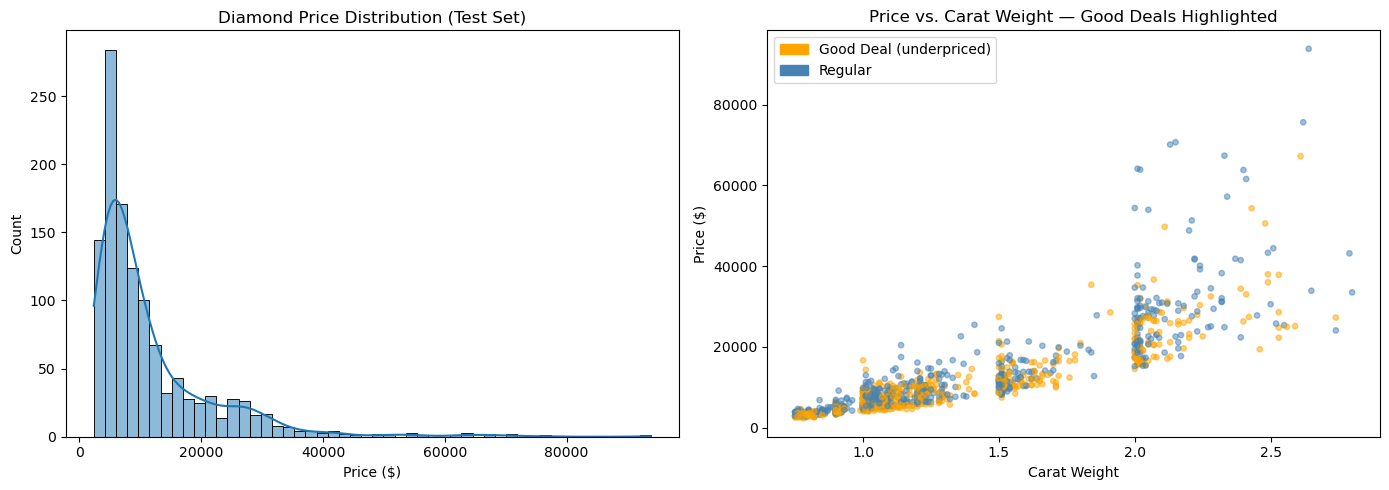

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
sns.histplot(test_df['Price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Diamond Price Distribution (Test Set)')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

# Price vs Carat Weight (Good Deals highlighted)
colors = test_df['Good_Deal'].map({True: 'orange', False: 'steelblue'})
axes[1].scatter(test_df['Carat Weight'], test_df['Price'], c=colors, alpha=0.5, s=15)
axes[1].set_title('Price vs. Carat Weight — Good Deals Highlighted')
axes[1].set_xlabel('Carat Weight')
axes[1].set_ylabel('Price ($)')
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='orange', label='Good Deal (underpriced)'),
    Patch(color='steelblue', label='Regular')
])

plt.tight_layout()
plt.show()